# **Geocodificación y análisis del vecino más cercano**

En esta sesión, aprenderemos a geocodificar la lista de direcciones de OpenStreetMap en coordenadas y a realizar un Análisis de Vecinos Más Próximos (ANP) para encontrar el punto más cercano al objetivo desde una colección de datos. En esta lección, repasaremos diferentes tipos de manipulación de datos y análisis espacial, especialmente aprenderemos a escribir una función de definición para el ANP.

Después de esta sesión, comprenderás cómo:

* Convertir nombres de ubicaciones en coordenadas

* Geocodificar un conjunto de direcciones para coordinar datos de OpenStreetMap

* Traza la ubicación de esas direcciones en un mapa

* Realizar consultas espaciales. Por ejemplo: encontrar puntos en un polígono.

* Encuentre las ubicaciones o puntos más cercanos entre dos conjuntos de datos.

## **1. Introducción a la geocodificación en Geopandas**
Geocoding Es el proceso que permite geopandas convertir nombres de lugares o direcciones en ubicaciones terrestres mediante Geopy y otras bibliotecas de geocodificación facilitan la localización de coordenadas de direcciones, ciudades, países y puntos de referencia en todo el mundo mediante proveedores de servicios web. Los servicios de geocodificación que ofrece Geopy incluyen:

* Servicio de geocodificación mundial de ArcGIS

* API de geocodificación de Google

* API abiertas de MapQuest

* etc.

La mayoría de los proveedores de servicios disponibles pueden requerir parámetros como claves API, y generalmente no son gratuitos. Por lo tanto, el servicio más común, y a menudo gratuito, es Open Street Map Nominatim .

**a. Geocodificación a partir de una lista de nombres**

Ahora geocodificaremos diferentes nombres de distritos de la ciudad de Nueva York usando el conjunto de datos del geopandasdirectorio y representaremos gráficamente esas ubicaciones junto con el límite detallado del distrito.

In [ ]:
!pip install geodatasets -q

In [ ]:
# Importar la herramienta de geocodificación
import geopandas as gpd
from geopandas.tools import geocode

In [ ]:
import geopandas as gpd
from geodatasets import get_path

# Utilice geodatasets para encontrar la ruta y luego geopandas para leerla
path = get_path("nybb")
new_york = gpd.read_file(path)

# V primeras filas
new_york.head()

,BoroCode,BoroName,Shape_Leng,Shape_Area,geometry
0,5,Staten Island,330470.010332,1.623820e+09,"MULTIPOLYGON (((970217.022 145643.332, 970227...."
1,4,Queens,896344.047763,3.045213e+09,"MULTIPOLYGON (((1029606.077 156073.814, 102957..."
2,3,Brooklyn,741080.523166,1.937479e+09,"MULTIPOLYGON (((1021176.479 151374.797, 102100..."
3,1,Manhattan,359299.096471,6.364715e+08,"MULTIPOLYGON (((981219.056 188655.316, 980940...."
4,2,Bronx,464392.991824,1.186925e+09,"MULTIPOLYGON (((1012821.806 229228.265, 101278..."


In [ ]:
# Extraer la lista de nombres del dataframe
boros = new_york.BoroName
boros

,BoroName
0,Staten Island
1,Queens
2,Brooklyn
3,Manhattan
4,Bronx


Con una lista de nombres de distritos que creamos anteriormente, podemos geocodificar estos nombres usando la función de geocodificación de Geopandas llamada geocode()

In [ ]:
from geopandas.tools import geocode

# Geocodificar direcciones usando Nominatim. Aquí, uso el nombre de usuario "geopy_osm"
geo = geocode(boros, provider='nominatim', user_agent='geopy_osm', timeout=4)

# Imprimir resultado
geo

,geometry,address
0,POINT (-74.1496 40.58346),"Staten Island, Richmond County, New York, Unit..."
1,POINT (-73.82831 40.71351),"Queens, Queens County, New York, United States"
2,POINT (-73.94972 40.6526),"Brooklyn, Kings County, New York, United States"
3,POINT (-73.98553 40.75796),"Manhattan, New York County, New York, United S..."
4,POINT (-73.87859 40.84665),"The Bronx, Bronx County, New York, United States"


Como puedes ver, a partir del nombre de los distritos podemos recuperar la geometría de cada ubicación como objetos puntuales y también direcciones en un formato bien escrito.

Ahora vamos a trazar estas ubicaciones en el mapa de la ciudad de Nueva York.

In [ ]:
import matplotlib.pyplot as plt

Antes de trazar, debemos confirmar que tanto la ubicación como el límite del área tengan el mismo sistema de referencia de coordenadas.

In [ ]:
# confirmar crs
new_york.crs == geo.crs

False

Bien, vamos a hacer coincidir su sistema de coordenadas.

In [ ]:
# cambiar crs
New_York = new_york.to_crs(geo.crs)

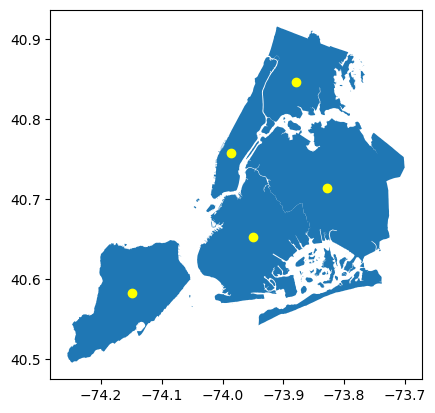

In [ ]:
# Vamos a trazar la ubicación de los distritos en un mapa
ax = New_York.plot()
geo.plot(ax=ax, color='yellow')

plt.show();

## **Geocodificación a partir del archivo de direcciones**

Aquí, geocodificaremos las direcciones en el estado de Nueva York almacenadas en un archivo de texto llamado address_random.txt.

Las primeras 6 filas de datos se ven así:

identificación; dirección

100; 141 Washington Ave Extensión Albany NY 12205

101; 2055 Cataratas del Niágara Blvd Amherst NY 14228

102; 297 Grant Avenue Auburn NY 13021

103; 4133 Veterans Memorial Drive Batavia NY 14020

104; 3191 Condado rd 10 Canandaigua NY 14424

In [ ]:
# Primero, importa los módulos necesarios.
import pandas as pd
import geopandas as gpd
from geopandas.tools import geocode
import time
from geopandas.tools import geocode

In [ ]:
#from google.colab import drive
#drive.mount('/content/drive')

In [ ]:
# determinar la ruta del archivo
fp = 'address_random.txt'

# Read address file
data = pd.read_csv(fp, delimiter = ';')

In [ ]:
# Vamos a revisar el archivo
print('The total address is:',len(data))

data

The total address is: 100


,id,dirección
0,100,141 Washington Ave Extension Albany NY 12205
1,101,2055 Niagara Falls Blvd Amherst NY 14228
2,102,297 Grant Avenue Auburn NY 13021
3,103,4133 Veterans Memorial Drive Batavia NY 14020
4,104,3191 County Road 4 Canandaigua NY 14424
...,...,...
95,195,405 Lexington Ave New York NY 10174
96,196,1 Central Park West New York NY 10023
97,197,725 Fifth Ave New York NY 10022
98,198,1000 West Ave Rochester NY 14611


In [ ]:
results = []
for addr in data['dirección']:
    try:
        g = geocode(addr, provider='nominatim', user_agent='autogis_xx', timeout=4)
        results.append(g)
        time.sleep(1)  # espera 1 segundo entre consultas
    except Exception as e:
        print(f"Error con {addr}: {e}")
geo_address = gpd.GeoDataFrame(pd.concat(results, ignore_index=True))

In [ ]:
geo_address

/usr/local/lib/python3.13/dist-packages/geopandas/geoseries.py:906: UserWarning: GeoSeries.notna() previously returned False for both missing (None) and empty geometries. Now, it only returns False for missing values. Since the calling GeoSeries contains empty geometries, the result has changed compared to previous versions of GeoPandas.
Given a GeoSeries 's', you can use '~s.is_empty & s.notna()' to get back the old behaviour.

To further ignore this warning, you can do: 
import warnings; warnings.filterwarnings('ignore', 'GeoSeries.notna', UserWarning)
  return self.notna()


,geometry,address
0,POINT (-73.84703 42.69495),"Walmart Supercenter, 141, Washington Avenue Ex..."
1,POINT (-78.82218 43.011),"2055, Niagara Falls Boulevard, Town of Amherst..."
2,POINT (-76.54815 42.95406),"Walmart Supercenter, 297, Grant Avenue, City o..."
3,POINT (-78.20765 43.01428),"4133, Veterans Memorial Drive, City of Batavia..."
4,POINT (-77.24777 42.90135),"3191, County Road 4, Town of Canandaigua, Onta..."
...,...,...
95,POINT (-73.97553 40.75191),"405, Lexington Avenue, Midtown, Manhattan Comm..."
96,POINT (-73.98154 40.76915),"Trump International Hotel and Tower, 1, Centra..."
97,POINT (-73.94537 40.80216),"5th Avenue, Manhattan Community Board 11, Manh..."
98,POINT (-77.66814 43.14685),"Pfaudler, 1000, West Avenue, City of Rochester..."


# **Unión de tablas**
En los análisis SIG, la unión de tablas es un procedimiento que combina datos de diferentes tablas basándose en un atributo clave común. En Python, esto se puede realizar fácilmente en Pandas/Geopandas mediante join(). Para unir dos tablas, debemos asegurarnos de que el orden y el número de registros coincidan en ambos DataFrame.

Ahora, usaremos join()-function para fusionar datay geo_addressunir en función del índice (por defecto) ya que ambos DataFrame ya tienen el mismo orden y número de filas.

In [ ]:
join_df = geo_address.join(data)
join_df.head()

/usr/local/lib/python3.13/dist-packages/geopandas/geoseries.py:906: UserWarning: GeoSeries.notna() previously returned False for both missing (None) and empty geometries. Now, it only returns False for missing values. Since the calling GeoSeries contains empty geometries, the result has changed compared to previous versions of GeoPandas.
Given a GeoSeries 's', you can use '~s.is_empty & s.notna()' to get back the old behaviour.

To further ignore this warning, you can do: 
import warnings; warnings.filterwarnings('ignore', 'GeoSeries.notna', UserWarning)
  return self.notna()


,geometry,address,id,dirección
0,POINT (-73.84703 42.69495),"Walmart Supercenter, 141, Washington Avenue Ex...",100,141 Washington Ave Extension Albany NY 12205
1,POINT (-78.82218 43.011),"2055, Niagara Falls Boulevard, Town of Amherst...",101,2055 Niagara Falls Blvd Amherst NY 14228
2,POINT (-76.54815 42.95406),"Walmart Supercenter, 297, Grant Avenue, City o...",102,297 Grant Avenue Auburn NY 13021
3,POINT (-78.20765 43.01428),"4133, Veterans Memorial Drive, City of Batavia...",103,4133 Veterans Memorial Drive Batavia NY 14020
4,POINT (-77.24777 42.90135),"3191, County Road 4, Town of Canandaigua, Onta...",104,3191 County Road 4 Canandaigua NY 14424


Vamos a comprobar el tipo de join_df tabla.

In [ ]:
print(type(join_df))
print(join_df.crs)

<class 'geopandas.geodataframe.GeoDataFrame'>
EPSG:4326


Como resultado, tenemos un nuevo GeoDataFrame llamado [nombre del archivo] join_df donde tenemos las dos columnas originales y una nueva columna para [ nombre del archivo geometry]. Ahora es fácil guardarlo como un shapefile en nuestro directorio de resultados.

In [ ]:
import os
# 1. Definir la ruta del archivo
outfp = 'result/addresses.shp'

# 2. Crear la carpeta 'result' si no existe
if not os.path.exists('result'):
    os.makedirs('result')
    print("Carpeta 'result' creada con éxito.")

# 3. Guardar el GeoDataFrame
# Asegúrate de que join_df sea un GeoDataFrame (no un DataFrame normal)
join_df.to_file(outfp)

print(f"Archivo guardado correctamente en: {outfp}")

Archivo guardado correctamente en: result/addresses.shp


# **Trazando esas direcciones en el límite del estado de Nueva York**

Aquí, haremos un gráfico de esas direcciones en el límite del estado de Nueva York para poder visualizar dónde se encuentran exactamente en un mapa.

Primero, importemos el límite del estado de Nueva York a Python.

In [ ]:
# Establecer ruta de archivo
fp = "output.geojson"

# Leer archivo usando gpd.read_file()
ny_state = gpd.read_file(fp)

In [ ]:
# Alineación del sistema de coordenadas del límite y las direcciones
#NY_state = ny_state.to_crs(geo_address.crs)

NY_state = ny_state.to_crs("EPSG:4326")

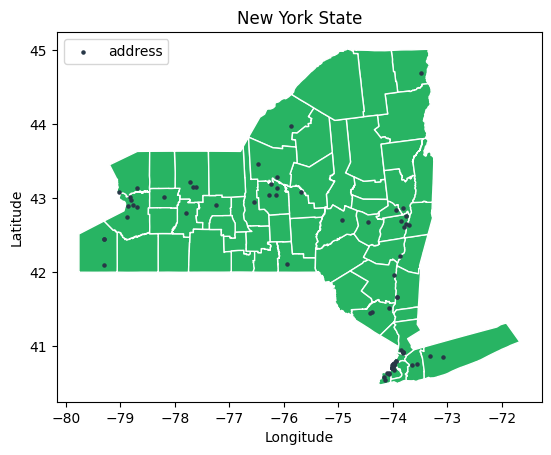

In [ ]:
# Vamos a trazar las ubicaciones en un mapa
ax = NY_state.plot(facecolor='#28B463', edgecolor='white')
geo_address.plot(ax=ax, color='#283747', markersize = 5, label = 'address')

# Personaliza la trama
plt.title('New York State')
plt.xlabel('Longitude')
plt.ylabel('Latitude')
plt.legend(loc=2) # 2 is for 'upper left'
plt.savefig('result/addresses in New York.png', dpi = 150)

plt.show();


# **Punto en el polígono**
**¿Cómo podemos comprobar si un punto está dentro o fuera de un polígono?**

Determinar si un punto se encuentra dentro o fuera de un área es una operación geoespacial básica (por ejemplo, seleccionar datos según su ubicación). En nuestro caso, queremos seleccionar todos los puntos de datos o direcciones en la zona oeste del estado de Nueva York.

Hay dos formas básicas de realizar la prueba Punto en Polígono usando Shapely: 1. usar .within(), una función para comprobar si un punto está dentro de un polígono 2. usar .contains(), una función para comprobar si un polígono contiene un punto

Para obtener más información sobre otras funciones operativas, como intersectar, tocar, etc., consulte la documentación de Shapely .

**Consulta espacial**

Fundamentalmente, las consultas espaciales son el primer paso típico del flujo de trabajo en el análisis espacial. Comencemos extrayendo la zona oeste del límite del estado de Nueva York que importamos anteriormente.

In [ ]:
# Recordar el límite del estado de Nueva York
NY_state.head()

,NAME,ABBREV,GNIS_ID,FIPS_CODE,SWIS,NYSP_ZONE,POP1990,POP2000,POP2010,POP2020,DOS_LL,DOSLL_DATE,NYC,CALC_SQ_MI,DATEMOD,Shape_Leng,Shape_Area,geometry
0,Albany,ALBA,974099,36001,010000,East,292594,294565,304204,314848,None,None,N,532.791779,2017-11-10,166077.834242,1.379924e+09,"POLYGON ((-73.70733 42.78605, -73.70397 42.783..."
1,Allegany,ALLE,974100,36003,020000,West,50470,49927,48946,46456,None,None,N,1035.209131,2019-04-26,210499.339692,2.681179e+09,"POLYGON ((-78.29218 42.5214, -78.29047 42.5214..."
2,Bronx,BRON,974101,36005,600000,Long Island,1203789,1332650,1385108,1472654,None,None,Y,57.472148,2019-10-04,57253.861278,1.488522e+08,"POLYGON ((-73.86567 40.90219, -73.863 40.90144..."
3,Broome,BROO,974102,36007,030000,Central,212160,200536,200600,198683,None,None,N,715.287465,2019-04-26,227933.332021,1.852586e+09,"POLYGON ((-75.86416 42.41554, -75.86379 42.413..."
4,Cattaraugus,CATT,974103,36009,040000,West,84234,83955,80317,77042,None,None,N,1324.309219,2019-04-26,276084.505177,3.429945e+09,"POLYGON ((-79.02148 42.53804, -79.01937 42.537..."


In [ ]:
# consulta espacial
west_ny = NY_state.loc[NY_state['NYSP_ZONE'] == 'West']

# Restablecer el índice después de la consulta
west_ny.reset_index(drop=True, inplace=True)

west_ny.head()

,NAME,ABBREV,GNIS_ID,FIPS_CODE,SWIS,NYSP_ZONE,POP1990,POP2000,POP2010,POP2020,DOS_LL,DOSLL_DATE,NYC,CALC_SQ_MI,DATEMOD,Shape_Leng,Shape_Area,geometry
0,Allegany,ALLE,974100,36003,020000,West,50470,49927,48946,46456,None,None,N,1035.209131,2019-04-26,210499.339692,2.681179e+09,"POLYGON ((-78.29218 42.5214, -78.29047 42.5214..."
1,Cattaraugus,CATT,974103,36009,040000,West,84234,83955,80317,77042,None,None,N,1324.309219,2019-04-26,276084.505177,3.429945e+09,"POLYGON ((-79.02148 42.53804, -79.01937 42.537..."
2,Chautauqua,CHAU,974105,36013,060000,West,141895,139750,134905,127657,None,None,N,1507.794553,2019-04-26,247508.472122,3.905170e+09,"POLYGON ((-79.12588 42.56523, -79.12534 42.565..."
3,Erie,ERIE,974113,36029,140000,West,968532,950265,919040,954236,None,None,N,1221.970018,2017-10-30,327906.747486,3.164888e+09,"POLYGON ((-78.63596 43.09328, -78.63584 43.093..."
4,Genesee,GENE,974117,36037,180000,West,60060,60370,60079,58388,None,None,N,496.057048,2018-02-12,155397.082626,1.284782e+09,"POLYGON ((-78.404 43.13108, -78.39051 43.13134..."


Vamos a crear un mapa que muestre la ubicación de la zona seleccionada y los puntos de dirección superpuestos:

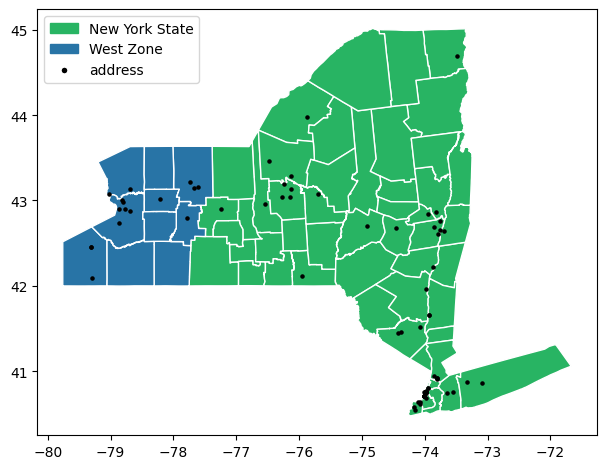

In [ ]:
import matplotlib.pyplot as plt
from matplotlib.patches import Patch
from matplotlib.lines import Line2D

# Crear una figura con un subgráfico
fig, ax = plt.subplots()

# Límite de parcela
NY_state.plot(ax=ax, facecolor='#28B463', edgecolor = 'white')
west_ny['geometry'].plot(ax=ax, facecolor='#2874A6', edgecolor = 'white')

# Trazar puntos de dirección
geo_address.plot(ax=ax, color='black', markersize=5)

# Agregar leyenda
plt.legend(loc=2, handles=[Patch(color='#28B463', label='New York State'),
                             Patch(color='#2874A6', label='West Zone'),
                             Line2D([0], [0], marker='o', color='w', label='address',
                          markerfacecolor='black', markersize=5)])
plt.tight_layout()


Claramente, hay ciertos puntos dentro del polígono azul. Realicemos una consulta adicional para obtener esos puntos usando within().

Pero, en primer lugar, within()solo funciona con un objeto de polígono. No es posible usar varios polígonos para la consulta. Dado que en la zona oeste hay muchos polígonos del condado, debemos fusionarlos en uno solo. Esto se puede lograr usando una función dissolve()de geopandas basada en un ID o nombre común.

**Disolver polígonos**

Veamos cómo podemos disolver esos polígonos en uno solo:

<Axes: >

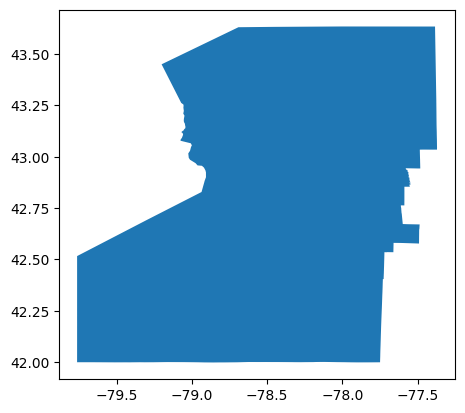

In [ ]:
# Polígono de disolución basado en la zona
polygon = west_ny.dissolve(by='NYSP_ZONE')
polygon.plot()

In [ ]:
polygon

,geometry,NAME,ABBREV,GNIS_ID,FIPS_CODE,SWIS,POP1990,POP2000,POP2010,POP2020,DOS_LL,DOSLL_DATE,NYC,CALC_SQ_MI,DATEMOD,Shape_Leng,Shape_Area
NYSP_ZONE,,,,,,,,,,,,,,,,,
West,"POLYGON ((-77.72373 42.45449, -77.72373 42.454...",Allegany,ALLE,974100,36003,020000,50470,49927,48946,46456,None,None,N,1035.209131,2019-04-26,210499.339692,2.681179e+09


**Punto de conducción en el polígono**

Ahora realicemos la consulta:

* Si hay demasiados puntos para la consulta, deberíamos habilitar shapely.speedups para que algunas consultas se ejecuten más rápido.

In [ ]:
import shapely.speedups
shapely.speedups.enable()

/tmp/ipykernel_3253/3808896212.py:2: FutureWarning: This function has no longer any effect, and will be removed in a future release. Starting with Shapely 2.0, equivalent speedups are always available
  shapely.speedups.enable()


Aquí, utilizamos esto para analizar el objeto de geometría Polygon real del GeoDataFrame..loc['West', 'geometry']polygon

In [ ]:
query = geo_address.within(polygon.loc['West', 'geometry'])
print(query)

0     False
1      True
2     False
3      True
4     False
      ...  
95    False
96    False
97    False
98     True
99    False
Length: 100, dtype: bool


Como resultado, obtenemos una matriz de valores booleanos para cada fila. En esta matriz, True significa que el punto está dentro del polígono, mientras que False significa que no lo está.

A partir de esta matriz de consulta, podemos seleccionar puntos de dirección que se encuentren dentro del polígono de la zona oeste utilizando .loc[] la función de Pandas.

In [ ]:
# Vamos a extraer puntos en un polígono (pip)
pip_data = geo_address.loc[query==True]
pip_data

,geometry,address
1,POINT (-78.82218 43.011),"2055, Niagara Falls Boulevard, Town of Amherst..."
3,POINT (-78.20765 43.01428),"4133, Veterans Memorial Drive, City of Batavia..."
7,POINT (-78.77821 42.90399),"East Thruway Plaza Drive, Thruway Plaza, Town ..."
13,POINT (-79.30928 42.45334),"10401, Bennett Road, Village of Fredonia, Town..."
14,POINT (-77.78753 42.79743),"4300, Lakeville Road, Village of Geneseo, Town..."
16,POINT (-77.73073 43.21536),"100, Elm Ridge Center Drive, Elm Ridge Center,..."
18,POINT (-78.87147 42.74058),"5360, Southwestern Boulevard, Town of Hamburg,..."
20,POINT (-79.30037 42.09704),"Subway, 350, East Fairmount Avenue, Village of..."
21,POINT (-78.69404 42.88239),"Walmart Supercenter, 4975, Transit Road, Town ..."
23,POINT (-78.6959 43.13795),"5885, South Transit Road, City of Lockport, To..."


Finalmente, podemos obtener el resultado de todos los puntos dentro de la zona oeste del estado de Nueva York.

In [ ]:
 # Seleccionemos también los puntos fuera del polígono (pop)
pop_data = geo_address.loc[query==False]

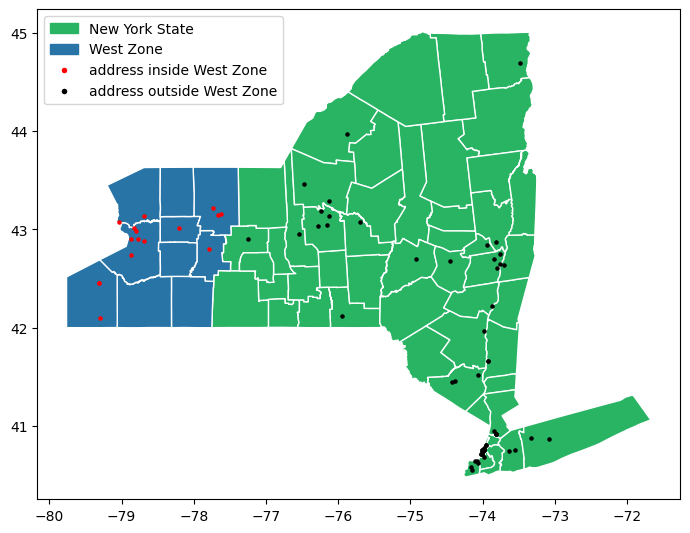

In [ ]:
import matplotlib.pyplot as plt
from matplotlib.patches import Patch
from matplotlib.lines import Line2D

# Crear una figura con un subgráfico
fig, ax = plt.subplots(figsize=(7,8))

# Límite de parcela
NY_state.plot(ax=ax, facecolor='#28B463', edgecolor = 'white')
west_ny['geometry'].plot(ax=ax, facecolor='#2874A6', edgecolor = 'white')

# Trazar puntos de dirección
pip_data.plot(ax=ax, color='red', markersize=5)
pop_data.plot(ax=ax, color='black', markersize=5)

# Agregar leyenda
plt.legend(loc=2, handles=[Patch(color='#28B463', label='New York State'),
                        Patch(color='#2874A6', label='West Zone'),
                        Line2D([0], [0], marker='o', color='w', label='address inside West Zone',
                          markerfacecolor='red', markersize=5),
                        Line2D([0], [0], marker='o', color='w', label='address outside West Zone',
                          markerfacecolor='black', markersize=5)])
plt.tight_layout()

¡Perfecto! Ahora tenemos un gráfico perfecto que muestra las direcciones dentro (rojo) y fuera de la zona oeste (negro), ¡que es exactamente lo que queríamos!

# **2. Análisis del vecino más cercano**

Para realizar un análisis de vecinos más cercanos en Python, utilizaremos una función de Shapely llamada nearest_point() . Esta función devolverá una tupla con los puntos más cercanos en las geometrías de entrada, en el mismo orden que estas.

**Punto más cercano con Shapely**

Mediante el uso de nearest_point()la función -, encontremos el destino más cercano de un grupo de puntos de destino al punto de origen.

In [1]:
from shapely.geometry import Point, MultiPoint
from shapely.ops import nearest_points

origin = Point(1.5, 1.3)
dest1, dest2, dest3 = Point(1, 2), Point(0.5, 1), Point(3, 0.542)

Para poder determinar el punto de destino más cercano al origen, necesitamos crear un objeto MultiPoint a partir de los puntos de destino.

In [2]:
destinations = MultiPoint([dest1, dest2, dest3])
print(destinations)

MULTIPOINT ((1 2), (0.5 1), (3 0.542))


Ahora podemos ver que todos los puntos de destino están representados como un único objeto MultiPoint. Apliquemos esto nearest_point()para encontrar el destino más cercano.

In [3]:
nearest_geoms = nearest_points(origin, destinations)

# Establecer el punto de origen
near_pt_1 = nearest_geoms[0]

# Establecer el punto más cercano
near_pt_2 = nearest_geoms[1]

print(nearest_geoms)
print(near_pt_1)
print(near_pt_2)

(<POINT (1.5 1.3)>, <POINT (1 2)>)
POINT (1.5 1.3)
POINT (1 2)


Miraflores es uno de los distritos con mayor densidad comercial y flujo turístico de Lima, Perú. Para cualquier negocio (comercio), la accesibilidad es un factor crítico de éxito.

## **El Desafío:**
Muchos clientes y empleados dependen del transporte público (corredores, buses convencionales). Si un local está a más de $400$ o $500$ metros de un paradero, se considera que tiene una "barrera de acceso" que puede reducir las ventas o dificultar la retención de personal.

## **La Solución:**
Al calcular el paradero más cercano y visualizar el "radio de caminata", el dueño del negocio puede:
* Optimizar el Marketing: "Estamos a solo $2$ minutos del Paradero Larco".
* Planificar Operaciones: Determinar rutas seguras para empleados que salen en turnos nocturnos.

In [4]:
!pip install contextily

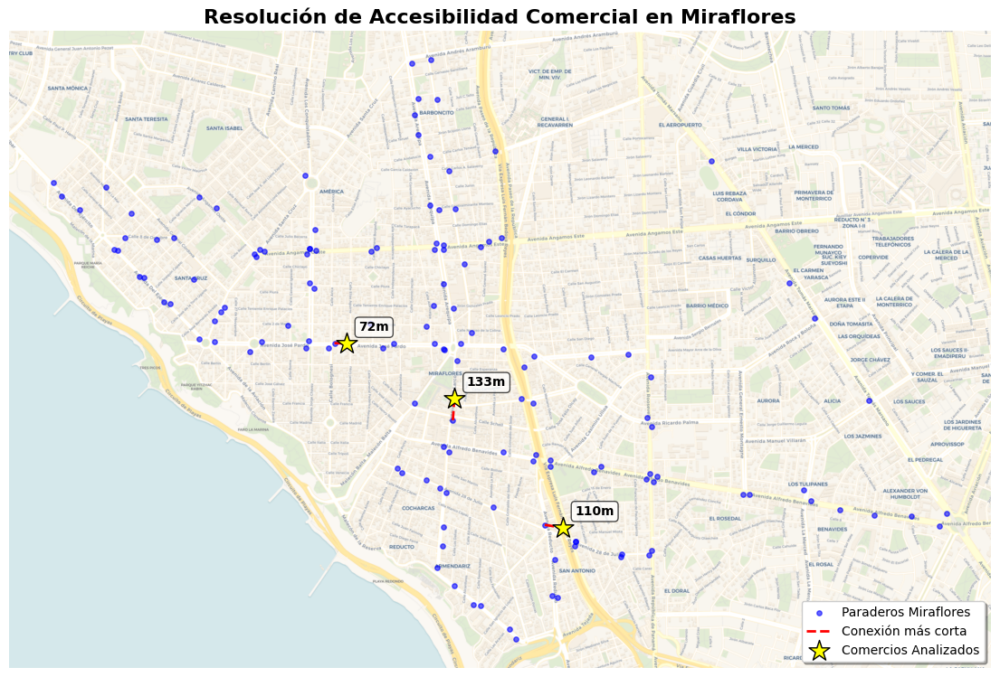

In [8]:
import geopandas as gpd
import pandas as pd
import matplotlib.pyplot as plt
import contextily as cx  # Para el mapa base de alta resolución
from shapely.ops import nearest_points
from shapely.geometry import Point, LineString

# 1. Cargar datos (Paraderos de Miraflores) [cite: 2, 3, 5]
try:
    path = 'Paraderos_Miraflores.shp'
    paraderos = gpd.read_file(path, encoding='utf-8')
except:
    paraderos = gpd.read_file(path, encoding='latin1')

# Proyectar a Web Mercator (EPSG:3857) para compatibilidad con Mapas Base
paraderos_wm = paraderos.to_crs(epsg=3857)

# 2. Definir Comercios (EPSG:3857)
comercios_data = {
    'negocio': ['Local Larco', 'Local Benavides', 'Local Pardo'],
    'lat': [-12.122, -12.129, -12.119],
    'lon': [-77.029, -77.023, -77.035]
}
gdf_comercios = gpd.GeoDataFrame(
    comercios_data,
    geometry=gpd.points_from_xy(comercios_data['lon'], comercios_data['lat']),
    crs="EPSG:4326"
).to_crs(epsg=3857)

# 3. Análisis Espacial
puntos_referencia = paraderos_wm.geometry.union_all()

def analizar_proximidad(row):
    cercano = nearest_points(row.geometry, puntos_referencia)[1]
    distancia = row.geometry.distance(cercano) # Distancia en metros
    linea = LineString([row.geometry, cercano])

    # Extraer info [cite: 3]
    match = paraderos_wm[paraderos_wm.geometry == cercano].iloc[0]
    nombre_p = f"{match['EJE']} / {match['APROXIMACI']}"
    return pd.Series([nombre_p, round(distancia, 2), linea],
                     index=['paradero', 'distancia_m', 'linea_geom'])

resultados = gdf_comercios.apply(analizar_proximidad, axis=1)
gdf_comercios[['paradero_cercano', 'distancia']] = resultados[['paradero', 'distancia_m']]
gdf_lineas = gpd.GeoDataFrame(resultados[['linea_geom']], geometry='linea_geom', crs=3857)

# 4. VISUALIZACIÓN DE ALTA RESOLUCIÓN
fig, ax = plt.subplots(figsize=(14, 12))

# Dibujar Red de Paraderos [cite: 2]
paraderos_wm.plot(ax=ax, color='blue', markersize=15, alpha=0.6, label='Paraderos Miraflores')

# Dibujar Líneas de conexión (Solución)
gdf_lineas.plot(ax=ax, color='red', linewidth=2, linestyle='--', label='Conexión más corta')

# Dibujar Comercios
gdf_comercios.plot(ax=ax, color='yellow', marker='*', markersize=300,
                  edgecolor='black', label='Comercios Analizados', zorder=5)

# 1. Pega tu API Key de CARTO aquí
api_key = "cb1_450d_1_987cd0e53b1e75b134b99734"

# 2. Define la URL de CARTO Voyager (usamos {{z}}, {{x}}, {{y}} en f-strings para escapar las llaves)
url_carto = f"https://basemaps.cartocdn.com/rastertiles/voyager/{{z}}/{{x}}/{{y}}.png?key={api_key}"

# 3. Pasa la URL a contextily
cx.add_basemap(ax, source=url_carto, zoom=16)

# Etiquetas de distancia
for x, y, dist in zip(gdf_comercios.geometry.x, gdf_comercios.geometry.y, gdf_comercios.distancia):
    ax.annotate(f"{int(dist)}m", xy=(x, y), xytext=(10, 10),
                textcoords="offset points", fontweight='bold',
                bbox=dict(boxstyle='round,pad=0.3', fc='white', alpha=0.7))

plt.title("Resolución de Accesibilidad Comercial en Miraflores", fontsize=16, fontweight='bold')
ax.set_axis_off() # Limpiar ejes para mejor estética
plt.legend(loc='lower right', frameon=True, shadow=True)
plt.show()

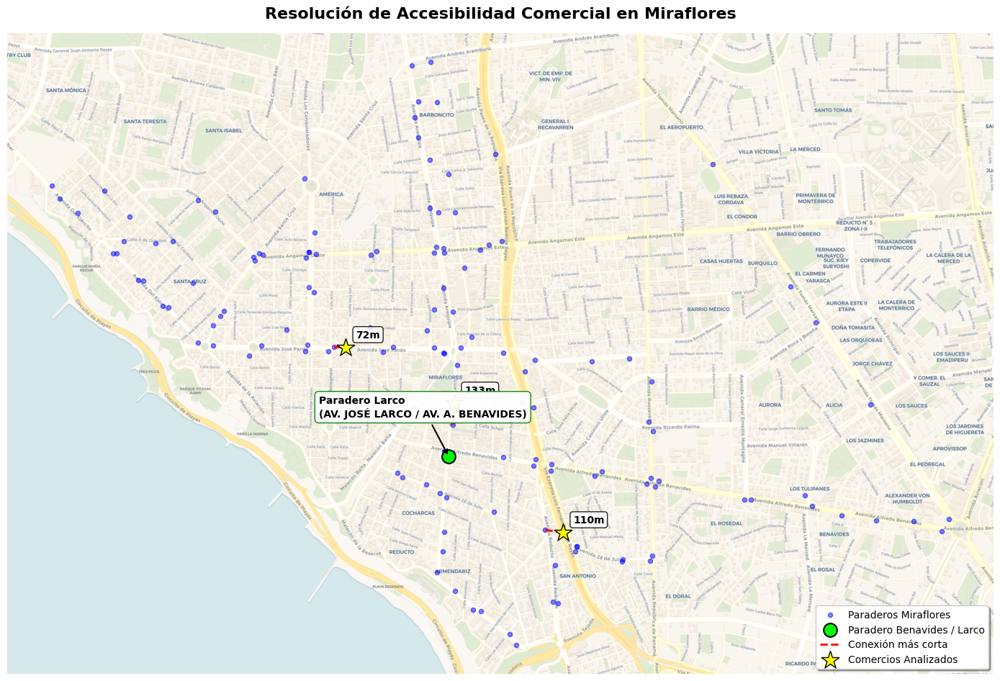

In [13]:
# --- FILTRAR Y DESTACAR PARADERO BENAVIDES / LARCO ---
paradero_benavides = paraderos_wm[
    (paraderos_wm['EJE'].str.contains('LARCO', na=False)) &
    (paraderos_wm['APROXIMACI'].str.contains('BENAVIDES', na=False))
]

# 4. VISUALIZACIÓN DE ALTA RESOLUCIÓN CON CARTO
fig, ax = plt.subplots(figsize=(14, 12))

# 1. Red General de Paraderos[cite: 2]
paraderos_wm.plot(ax=ax, color='blue', markersize=20, alpha=0.5, label='Paraderos Miraflores')

# 2. Paradero Benavides / Larco Destacado[cite: 2]
paradero_benavides.plot(
    ax=ax, color='lime', markersize=180, edgecolor='black', linewidth=1.5,
    zorder=6, label='Paradero Benavides / Larco'
)

# 3. Líneas de conexión más corta
gdf_lineas.plot(ax=ax, color='red', linewidth=2, linestyle='--', label='Conexión más corta', zorder=4)

# 4. Comercios Analizados
gdf_comercios.plot(ax=ax, color='yellow', marker='*', markersize=350,
                   edgecolor='black', label='Comercios Analizados', zorder=5)

# --- MAPA BASE DE CARTO ---
# Opción A: Usando el proveedor directo de contextily
#cx.add_basemap(ax, source=cx.providers.CartoDB.Voyager, zoom=16)

# Opción B: Si quieres pasar tu API Key directa para quitar la marca de agua, descomenta las siguientes 2 líneas:
api_key = "cb1_450d_1_987cd0e53b1e75b134b99734"
cx.add_basemap(ax, source=f"https://basemaps.cartocdn.com/rastertiles/voyager/{{z}}/{{x}}/{{y}}.png?key={api_key}", zoom=16)

# 5. Etiquetas y anotaciones

# Anotación destacada para el Paradero Benavides
for x, y, eje, aprox in zip(paradero_benavides.geometry.x, paradero_benavides.geometry.y,
                            paradero_benavides['EJE'], paradero_benavides['APROXIMACI']):
    ax.annotate(
        f"Paradero Larco\n({eje} / {aprox})",
        xy=(x, y), xytext=(-130, 40),
        textcoords="offset points", fontweight='bold', fontsize=10,
        arrowprops=dict(arrowstyle="->", color='black', lw=1.5),
        bbox=dict(boxstyle='round,pad=0.4', fc='white', ec='green', alpha=0.95),
        zorder=7
    )

# Etiquetas de distancia a los comercios
for x, y, dist in zip(gdf_comercios.geometry.x, gdf_comercios.geometry.y, gdf_comercios.distancia):
    ax.annotate(f"{int(dist)}m", xy=(x, y), xytext=(10, 10),
                textcoords="offset points", fontweight='bold',
                bbox=dict(boxstyle='round,pad=0.3', fc='white', alpha=0.85), zorder=6)

plt.title("Resolución de Accesibilidad Comercial en Miraflores", fontsize=16, fontweight='bold', pad=15)
ax.set_axis_off()
plt.legend(loc='lower right', frameon=True, shadow=True)
plt.tight_layout()
plt.show()

In [17]:
pip install osmnx -q


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 104.7/104.7 kB 6.6 MB/s eta 0:00:00


/tmp/ipykernel_4319/4290311863.py:31: DeprecationWarning: The 'unary_union' attribute is deprecated, use the 'union_all()' method instead.
  poligono_isocrona = gdf_nodos_5min.unary_union.convex_hull
/tmp/ipykernel_4319/4290311863.py:76: UserWarning: Legend does not support handles for PatchCollection instances.
See: https://matplotlib.org/stable/tutorials/intermediate/legend_guide.html#implementing-a-custom-legend-handler
  plt.legend(loc='lower right', frameon=True, shadow=True)
/tmp/ipykernel_4319/4290311863.py:77: UserWarning: Glyph 128205 (\N{ROUND PUSHPIN}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_4319/4290311863.py:77: UserWarning: Glyph 128664 (\N{ONCOMING AUTOMOBILE}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/usr/local/lib/python3.13/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 128205 (\N{ROUND PUSHPIN}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/usr/local/lib/python3.13/dist-packa

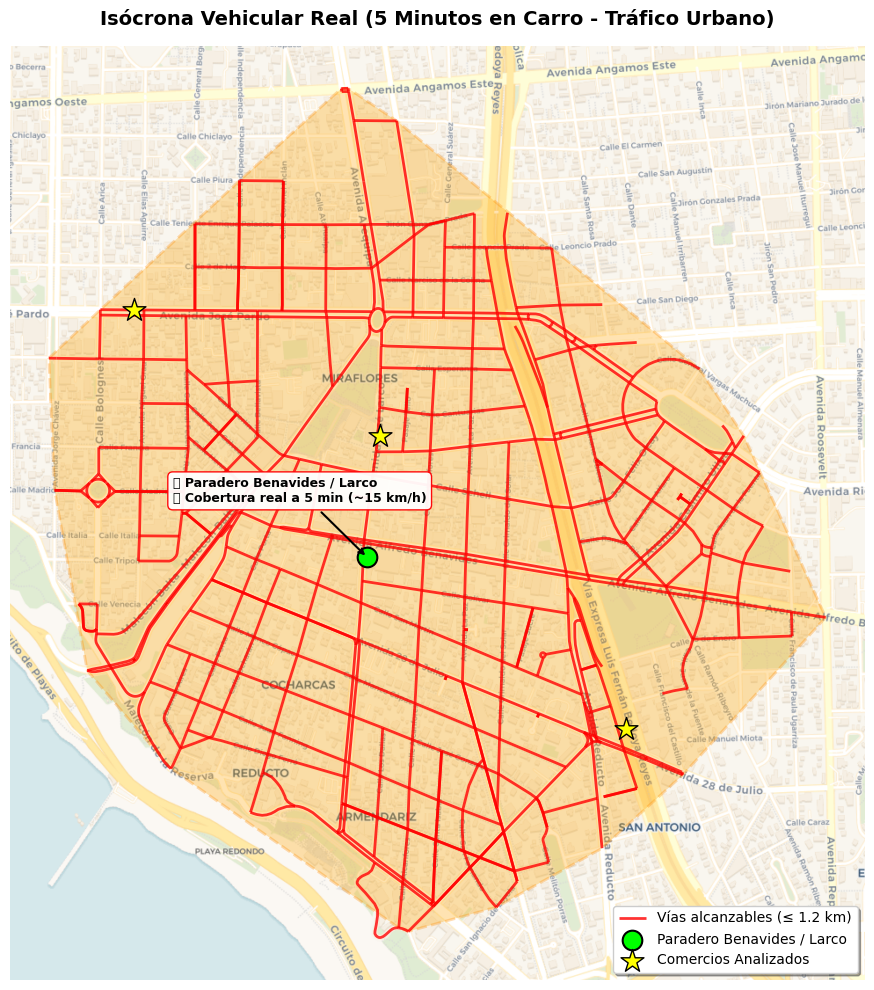

In [20]:
import geopandas as gpd
import matplotlib.pyplot as plt
import osmnx as ox
import networkx as nx
import contextily as cx

# 1. Obtener coordenadas del paradero Benavides / Larco
paradero_wgs84 = paradero_benavides.to_crs(epsg=4326)
lat = paradero_wgs84.geometry.y.values[0]
lon = paradero_wgs84.geometry.x.values[0]

# 2. Descargar red vial en un radio realista de 1.5 km
G = ox.graph_from_point((lat, lon), dist=1500, network_type='drive')

# 3. ASIGNAR VELOCIDAD URBANA REALISTA (15 km/h = ~4.16 m/s)
# Esto contempla semáforos, giros y tráfico moderado de Miraflores
velocidad_real_mps = (15 * 1000) / 3600  # 15 km/h a metros/segundo

for u, v, k, data in G.edges(keys=True, data=True):
    data['travel_time'] = data['length'] / velocidad_real_mps

# 4. Encontrar nodo más cercano
center_node = ox.distance.nearest_nodes(G, lon, lat)

# 5. Filtrar tramos alcanzables a 5 minutos (300 segundos)
subgraph = nx.ego_graph(G, center_node, radius=300, distance='travel_time')

# 6. Convertir a GeoDataFrames en Web Mercator (EPSG:3857)
gdf_rutas_5min = ox.graph_to_gdfs(subgraph, nodes=False).to_crs(epsg=3857)
gdf_nodos_5min = ox.graph_to_gdfs(subgraph, edges=False).to_crs(epsg=3857)
poligono_isocrona = gdf_nodos_5min.unary_union.convex_hull

# 7. GRAFICAR MAPA AJUSTADO CON CARTO
fig, ax = plt.subplots(figsize=(12, 10))

# A. Cobertura vehicular real a 5 min (área compacta)
gpd.GeoSeries([poligono_isocrona], crs=3857).plot(
    ax=ax, color='orange', alpha=0.3, edgecolor='darkorange', linewidth=2, linestyle='--', label='Área a 5 min en carro (tráfico real)'
)

# B. Calles transitables a 5 min
gdf_rutas_5min.plot(
    ax=ax, color='red', linewidth=2, alpha=0.8, label='Vías alcanzables (≤ 1.2 km)'
)

# C. Paradero Benavides / Larco
paradero_benavides.plot(
    ax=ax, color='lime', markersize=200, edgecolor='black', linewidth=1.5, zorder=6, label='Paradero Benavides / Larco'
)

# D. Comercios Analizados
gdf_comercios.plot(
    ax=ax, color='yellow', marker='*', markersize=300, edgecolor='black', zorder=5, label='Comercios Analizados'
)

# E. Mapa Base CARTO con tu API Key
api_key = "cb1_450d_1_987cd0e53b1e75b134b99734"
cx.add_basemap(
    ax,
    source=f"https://basemaps.cartocdn.com/rastertiles/voyager/{{z}}/{{x}}/{{y}}.png?key={api_key}",
    zoom=16
)

# Anotación
ax.annotate(
    "📍 Paradero Benavides / Larco\n🚘 Cobertura a 5 min (~15 km/h)",
    xy=(paradero_benavides.geometry.x.values[0], paradero_benavides.geometry.y.values[0]),
    xytext=(-140, 40), textcoords="offset points", fontweight='bold', fontsize=9,
    arrowprops=dict(arrowstyle="->", color='black', lw=1.5),
    bbox=dict(boxstyle='round,pad=0.4', fc='white', ec='red', alpha=0.95),
    zorder=7
)

plt.title("Isócrona Vehicular Real (5 Minutos en Carro - Tráfico Urbano)", fontsize=14, fontweight='bold', pad=15)
ax.set_axis_off()
plt.legend(loc='lower right', frameon=True, shadow=True)
plt.tight_layout()
plt.show()

In [19]:
# Evaluar si los comercios se encuentran dentro del polígono de 5 minutos en auto
comercios_alcanzables = gdf_comercios[gdf_comercios.geometry.within(poligono_isocrona)]

print(f"Comercios alcanzables a 5 minutos en auto: {len(comercios_alcanzables)}")

Comercios alcanzables a 5 minutos en auto: 3


/tmp/ipykernel_4319/1752684482.py:52: DeprecationWarning: The 'unary_union' attribute is deprecated, use the 'union_all()' method instead.
  poligono_base = gdf_nodos_base.unary_union.convex_hull
/tmp/ipykernel_4319/1752684482.py:58: DeprecationWarning: The 'unary_union' attribute is deprecated, use the 'union_all()' method instead.
  poligono_optimo = gdf_nodos_optimos.unary_union.convex_hull


Punto Optimo encontrado: Alcanza 49 zonas/hubs unicos de paraderos en 5 minutos.


/tmp/ipykernel_4319/1752684482.py:138: UserWarning: Legend does not support handles for PatchCollection instances.
See: https://matplotlib.org/stable/tutorials/intermediate/legend_guide.html#implementing-a-custom-legend-handler
  plt.legend(loc='lower right', frameon=True, shadow=True, facecolor='white', framealpha=0.95)


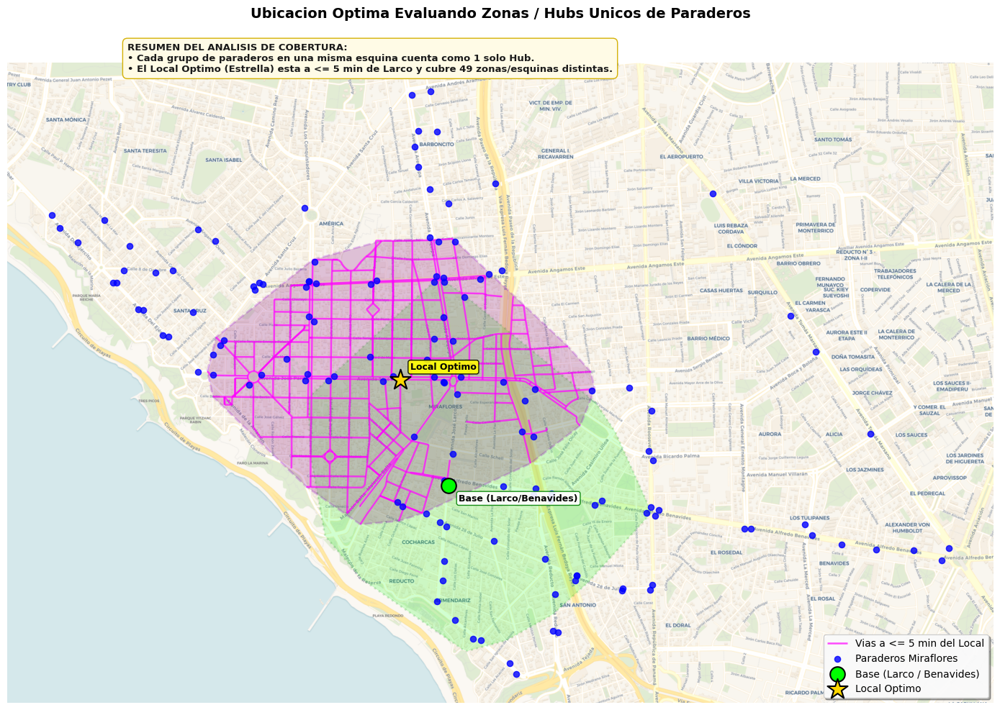

In [25]:
import geopandas as gpd
import matplotlib.pyplot as plt
import networkx as nx
import osmnx as ox
from shapely.geometry import Point
import contextily as cx

# 1. PREPARAR VELOCIDADES Y TIEMPOS DE VIAJE (15 km/h)
velocidad_mps = (15 * 1000) / 3600
for u, v, k, data in G.edges(keys=True, data=True):
    data['travel_time'] = data['length'] / velocidad_mps

# 2. SIMPLIFICACIÓN: CONVERTIR PARADEROS A NODOS Y UNIFICAR POR ESQUINA/HUB
paraderos_wgs84 = paraderos_wm.to_crs(epsg=4326)
paradero_nodes = ox.distance.nearest_nodes(G, X=paraderos_wgs84.geometry.x, Y=paraderos_wgs84.geometry.y)

# Agrupar esquinas únicas para que múltiples paraderos en un mismo cruce cuenten como 1 solo hub[cite: 11]
nodos_hubs_unicos = set(paradero_nodes)

# 3. IDENTIFICAR NODO DEL PARADERO BASE (LARCO / BENAVIDES)[cite: 2]
paradero_base_wgs84 = paradero_benavides.to_crs(epsg=4326)
lat_base = paradero_base_wgs84.geometry.y.values[0]
lon_base = paradero_base_wgs84.geometry.x.values[0]
center_node = ox.distance.nearest_nodes(G, lon_base, lat_base)

# Candidatos restringidos a <= 5 min (300 seg) desde el paradero Base
tiempos_desde_base = nx.single_source_dijkstra_path_length(G, center_node, cutoff=300, weight='travel_time')
nodos_candidatos_validos = list(tiempos_desde_base.keys())

# 4. EVALUAR COBERTURA DE ZONAS/HUBS ÚNICOS
max_hubs = -1
best_node = None

for node in nodos_candidatos_validos:
    tiempos_desde_candidato = nx.single_source_dijkstra_path_length(G, node, cutoff=300, weight='travel_time')
    nodos_alcanzables = set(tiempos_desde_candidato.keys())

    # Contar esquinas/hubs únicos alcanzados[cite: 11]
    hubs_alcanzados = len(nodos_alcanzables.intersection(nodos_hubs_unicos))

    if hubs_alcanzados > max_hubs:
        max_hubs = hubs_alcanzados
        best_node = node

# 5. GENERAR COBERTURAS Y GEOMETRÍAS
punto_optimo_wgs84 = Point(G.nodes[best_node]['x'], G.nodes[best_node]['y'])
gdf_punto_optimo = gpd.GeoDataFrame(geometry=[punto_optimo_wgs84], crs="EPSG:4326").to_crs(epsg=3857)

# Zona a 5 min de Base (Larco/Benavides)[cite: 2]
subgraph_base = nx.ego_graph(G, center_node, radius=300, distance='travel_time')
gdf_nodos_base = ox.graph_to_gdfs(subgraph_base, edges=False).to_crs(epsg=3857)
poligono_base = gdf_nodos_base.unary_union.convex_hull

# Cobertura a 5 min del Nuevo Punto Óptimo
subgraph_optimo = nx.ego_graph(G, best_node, radius=300, distance='travel_time')
gdf_rutas_optimas = ox.graph_to_gdfs(subgraph_optimo, nodes=False).to_crs(epsg=3857)
gdf_nodos_optimos = ox.graph_to_gdfs(subgraph_optimo, edges=False).to_crs(epsg=3857)
poligono_optimo = gdf_nodos_optimos.unary_union.convex_hull

print(f"Punto Optimo encontrado: Alcanza {max_hubs} zonas/hubs unicos de paraderos en 5 minutos.")

# 6. GRAFICAR EL MAPA SIN EMOJIS
fig, ax = plt.subplots(figsize=(14, 11))

# Área a 5 min de Larco/Benavides
gpd.GeoSeries([poligono_base], crs=3857).plot(
    ax=ax, color='lime', alpha=0.18, edgecolor='green',
    linewidth=2, linestyle=':', label='Zona a <= 5 min de Larco / Benavides'
)

# Cobertura a 5 min del Local Óptimo
gpd.GeoSeries([poligono_optimo], crs=3857).plot(
    ax=ax, color='purple', alpha=0.22, edgecolor='darkviolet',
    linewidth=2, linestyle='--', label=f'Cobertura del Local ({max_hubs} zonas unicas)'
)

# Rutas del Punto Óptimo
gdf_rutas_optimas.plot(
    ax=ax, color='magenta', linewidth=1.8, alpha=0.7, label='Vias a <= 5 min del Local'
)

# Paraderos Azules[cite: 9]
paraderos_wm.plot(
    ax=ax, color='blue', markersize=35, alpha=0.8, zorder=6, label='Paraderos Miraflores'
)

# Paradero Base (Larco/Benavides)[cite: 2]
paradero_benavides.plot(
    ax=ax, color='lime', marker='o', markersize=220, edgecolor='black', linewidth=1.5,
    zorder=8, label='Base (Larco / Benavides)'
)

# Punto Óptimo Encontrado
gdf_punto_optimo.plot(
    ax=ax, color='gold', marker='*', markersize=450, edgecolor='black', linewidth=1.5,
    zorder=8, label='Local Optimo'
)

# Mapa Base CARTO
api_key = "cb1_450d_1_987cd0e53b1e75b134b99734"
cx.add_basemap(
    ax,
    source=f"https://basemaps.cartocdn.com/rastertiles/voyager/{{z}}/{{x}}/{{y}}.png?key={api_key}",
    zoom=16
)

# Etiquetas compactas dentro del mapa[cite: 9]
x_base, y_base = paradero_benavides.geometry.x.values[0], paradero_benavides.geometry.y.values[0]
x_opt, y_opt = gdf_punto_optimo.geometry.x.values[0], gdf_punto_optimo.geometry.y.values[0]

ax.annotate(
    "Base (Larco/Benavides)",
    xy=(x_base, y_base), xytext=(10, -15),
    textcoords="offset points", fontweight='bold', fontsize=9,
    bbox=dict(boxstyle='round,pad=0.25', fc='white', ec='green', alpha=0.9),
    zorder=9
)

ax.annotate(
    "Local Optimo",
    xy=(x_opt, y_opt), xytext=(10, 10),
    textcoords="offset points", fontweight='bold', fontsize=9,
    bbox=dict(boxstyle='round,pad=0.25', fc='yellow', ec='black', alpha=0.9),
    zorder=9
)

plt.title("Ubicacion Optima Evaluando Zonas / Hubs Unicos de Paraderos", fontsize=14, fontweight='bold', pad=45)

# Cartel resumen fuera del margen del mapa[cite: 9]
fig.text(
    0.13, 0.89,
    f"RESUMEN DEL ANALISIS DE COBERTURA:\n• Cada grupo de paraderos en una misma esquina cuenta como 1 solo Hub.\n• El Local Optimo (Estrella) esta a <= 5 min de Larco y cubre {max_hubs} zonas/esquinas distintas.",
    fontsize=9.5, fontweight='bold', color='#1a1a1a',
    bbox=dict(boxstyle='round,pad=0.5', fc='#fffbe6', ec='#d4b106', alpha=1.0)
)

ax.set_axis_off()
plt.legend(loc='lower right', frameon=True, shadow=True, facecolor='white', framealpha=0.95)
plt.tight_layout()
plt.show()